##Análise Exploratória de Dados (EDA) e Verificação de Estrutura

Identificando tipos de dados, valores nulos, quantidade de registros únicos e
granularidade dos dados.

In [ ]:
import pandas as pd
import numpy as np

path = "/content/dataset-prontpet.csv"
df = pd.read_csv(path, encoding='utf-8-sig', sep=';')

print("=" * 60)
print("1. VISÃO GERAL DO DATASET")
print("=" * 60)
print(f"Total de Registros: {df.shape[0]}")
print(f"Total de Colunas: {df.shape[1]}")

print("\n" + "=" * 60)
print("2. ENTIDADES E UNICIDADE DE REGISTROS")
print("=" * 60)
print(f"Pets Únicos: {df['ID_PET'].nunique()}")
print(f"Consultas Únicas: {df['ID_CONSULTATION'].nunique()}")
print(f"Prontuários Únicos: {df['ID_MEDICAL_RECORD'].nunique()}")

print("\n" + "=" * 60)
print("3. RESUMO DE VALORES AUSENTES (NULOS)")
print("=" * 60)
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df)) * 100
df_nulos = pd.DataFrame({'Absoluto': nulos, 'Porcentagem (%)': nulos_pct})
print(df_nulos[df_nulos['Absoluto'] > 0])

print("\n" + "=" * 60)
print("4. TIPOS DE DADOS E AMOSTRAGEM")
print("=" * 60)
print(df.dtypes)

1. VISÃO GERAL DO DATASET
Total de Registros: 289
Total de Colunas: 26

2. ENTIDADES E UNICIDADE DE REGISTROS
Pets Únicos: 20
Consultas Únicas: 100
Prontuários Únicos: 20

3. RESUMO DE VALORES AUSENTES (NULOS)
                     Absoluto  Porcentagem (%)
PET_ALLERGY               196        67.820069
CHRONIC_PET_DISEASE        39        13.494810
IS_CASTRATED_PET            1         0.346021

4. TIPOS DE DADOS E AMOSTRAGEM
ID_CONSULTATION                  int64
CONSULTATION_DATE               object
SYMPTOMS                        object
DIAGNOSIS                       object
PET_WEIGHT                      object
ID_PET                           int64
PET_NAME                        object
SPECIES                         object
BREED                           object
PET_BIRTH_DATE                  object
PET_GENDER                      object
ID_TUTOR                         int64
TUTOR_NAME                      object
ID_VACCINE                       int64
VACCINE_NAME            

##Pré-processamento, Limpeza e Agrupamento

###Carrega o dataset bruto, limpa o nome das colunas, trata tipos de dados e consolida o nível de granularidade por ID_CONSULTATION.

**Padronização e Limpeza:** Corrige os separadores decimais do peso (PET_WEIGHT) e converte as strings de data para o formato datetime do Pandas.

**Feature Engineering Inicial:** Cria a coluna PET_AGE_YEARS (idade precisa do pet na data do atendimento) e trata os valores nulos de alergias e doenças crônicas substituindo por "Nenhuma" (o que também serve como dado categórico útil para o modelo).

**Consolidação Granular:** Agrupa o dataset por ID_CONSULTATION, transformando o número de vacinas em uma métrica agregada (TOTAL_VACCINES_REGISTERED), visto que linhas duplicadas ocorrem por conta da relação de 1-para-Muitos com as vacinas (ID_VACCINE), dessa forma eliminamos as linhas duplicadas sem perder nenhuma informação clínica.

In [ ]:
# Padronizando o nome das colunas (removendo caracteres estranhos de BOM se existirem)
df.columns = df.columns.str.replace('ï»¿', '').str.strip()

print(f"Linhas antes da consolidação (grão de vacina): {df.shape[0]}")

# Tratamento de colunas numéricas
if df['PET_WEIGHT'].dtype == 'object':
  df['PET_WEIGHT'] = df['PET_WEIGHT'].str.replace(',', '.').astype(float)

# Tratamento de colunas de data
df['CONSULTATION_DATE'] = pd.to_datetime(df['CONSULTATION_DATE'], format='%d/%m/%Y', errors='coerce')
df['PET_BIRTH_DATE'] = pd.to_datetime(df['PET_BIRTH_DATE'], format='%d/%m/%Y %H:%M', errors='coerce')

# Criação de feature de Idade do Pet em anos no momento da consulta
df['PET_AGE_YEARS'] = (df['CONSULTATION_DATE'] - df['PET_BIRTH_DATE']).dt.days / 365.25 # O 365.25 é utilizado para considerar aproximadamente os anos bissextos.

# Tratamento de valores nulos textuais importantes
df['PET_ALLERGY'] = df['PET_ALLERGY'].fillna('Nenhuma')
df['CHRONIC_PET_DISEASE'] = df['CHRONIC_PET_DISEASE'].fillna('Nenhuma')

# Agrupamento por Consulta (ID_CONSULTATION)
# Pegamos a primeira ocorrência da consulta, contando quantas vacinas ele possui
# associadas naquele momento.
agregacoes = {
  'CONSULTATION_DATE': 'first',
  'SYMPTOMS': 'first',
  'DIAGNOSIS': 'first',
  'PET_WEIGHT': 'first',
  'ID_PET': 'first',
  'PET_NAME': 'first',
  'SPECIES': 'first',
  'BREED': 'first',
  'PET_AGE_YEARS': 'first',
  'PET_GENDER': 'first',
  'TUTOR_NAME': 'first',
  'PET_BLOOD_TYPE': 'first',
  'PET_ALLERGY': 'first',
  'CHRONIC_PET_DISEASE': 'first',
  'IS_CASTRATED_PET': 'first',
  'CLINIC_NAME': 'first',
  'RISK': 'first',
  'ID_VACCINE': 'count' # Conta quantas vacinas estão vinculadas à consulta
}

df_consolidado = df.groupby('ID_CONSULTATION').agg(agregacoes).reset_index()
df_consolidado.rename(columns={'ID_VACCINE': 'TOTAL_VACCINES_REGISTERED'}, inplace=True)

print(f"Linhas após a consolidação (grão de consulta única): {df_consolidado.shape[0]}")
print("\n--- Amostra do Dataset Consolidado ---")
print(df_consolidado[['ID_CONSULTATION', 'PET_NAME', 'SYMPTOMS', 'PET_AGE_YEARS', 'TOTAL_VACCINES_REGISTERED', 'RISK']].head())

Linhas antes da consolidação (grão de vacina): 289
Linhas após a consolidação (grão de consulta única): 100

--- Amostra do Dataset Consolidado ---
   ID_CONSULTATION PET_NAME                            SYMPTOMS  \
0                1      Rex  Nenhum sintoma - checkup de rotina   
1                2      Rex                         Leve apatia   
2                3      Rex                         Leve apatia   
3                4      Rex  Nenhum sintoma - checkup de rotina   
4                5     Luna                    Bom estado geral   

   PET_AGE_YEARS  TOTAL_VACCINES_REGISTERED  RISK  
0       4.071184                          2     0  
1       4.246407                          2     0  
2       4.744695                          2     0  
3       5.722108                          2     0  
4       8.610541                          4     0  


##Encodings

**PET_AGE_YEARS** & **IS_SENIOR**: A idade é um fator biológico crucial para predizer riscos de complicações e doenças degenerativas.

**HAS_ALLERGY** e **HAS_CHRONIC_DISEASE**: Transformam os textos longos de diagnósticos prévios em colunas binárias numéricas reutilizáveis pelo modelo.

**pd.get_dummies:** Transforma atributos como Espécie (Cachorro/Gato), Gênero (Macho/Fêmea) e Tipos Sanguíneos em vetores numéricos compatíveis com scikit-learn/XGBoost, prevenindo problemas de encoding ordinal espúrio.

In [ ]:
# Indicador de Pet Idoso (> 7 anos)
df_consolidado['IS_SENIOR'] = (df_consolidado['PET_AGE_YEARS'] >= 7.0).astype(int)

# Indicadores de Alergia e Doença Crônica
df_consolidado['HAS_ALLERGY'] = (df_consolidado['PET_ALLERGY'] != 'Nenhuma').astype(int)
df_consolidado['HAS_CHRONIC_DISEASE'] = (df_consolidado['CHRONIC_PET_DISEASE'] != 'Nenhuma').astype(int)



# Flag Castrado (1 para S, 0 para N/Outro)
df_consolidado['IS_CASTRATED'] = df_consolidado['IS_CASTRATED_PET'].apply(lambda x: 1 if str(x).upper().startswith('S') else 0)

# Seleção e Encodings de Variáveis Relevantes
# Selecionando apenas preditores (X) e a variável alvo (y)
colunas_features = [
    'SPECIES', 'PET_GENDER', 'PET_BLOOD_TYPE', 'PET_WEIGHT',
    'PET_AGE_YEARS', 'IS_SENIOR', 'IS_CASTRATED',
    'HAS_ALLERGY', 'HAS_CHRONIC_DISEASE', 'TOTAL_VACCINES_REGISTERED'
]

X = df_consolidado[colunas_features].copy()
y = df_consolidado['RISK'].astype(int)

# One-Hot Encoding para variáveis categóricas
X_encoded = pd.get_dummies(X, columns=['SPECIES', 'PET_GENDER', 'PET_BLOOD_TYPE'], drop_first=True, dtype=int)


print(f"Dimensões finais de X (Features): {X_encoded.shape}")
print(f"Dimensões de y (Target): {y.shape}")
print("\nNovas colunas geradas no dataset de treino:")
print(list(X_encoded.columns))

Dimensões finais de X (Features): (100, 14)
Dimensões de y (Target): (100,)

Novas colunas geradas no dataset de treino:
['PET_WEIGHT', 'PET_AGE_YEARS', 'IS_SENIOR', 'IS_CASTRATED', 'HAS_ALLERGY', 'HAS_CHRONIC_DISEASE', 'TOTAL_VACCINES_REGISTERED', 'SPECIES_Gato', 'PET_GENDER_Macho', 'PET_BLOOD_TYPE_AB', 'PET_BLOOD_TYPE_B', 'PET_BLOOD_TYPE_DEA 1.1+', 'PET_BLOOD_TYPE_DEA 1.1-', 'PET_BLOOD_TYPE_DEA 4+']


##Divisão Treino/Teste e Treinamento de Algoritmos Preditivos

In [ ]:
# ============================================================
# ETAPA 4: DIVISÃO TREINO/TESTE E TREINAMENTO DOS MODELOS
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

# 1. Divisão Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Tamanho do treino (X_train): {X_train.shape[0]} amostras")
print(f"Tamanho do teste (X_test): {X_test.shape[0]} amostras")
print(f"Proporção do Target no treino:\n{y_train.value_counts(normalize=True).round(2).to_dict()}")
print(f"Proporção do Target no teste:\n{y_test.value_counts(normalize=True).round(2).to_dict()}")

# 2. Padronização de escalas das features numéricas (necessária para Regressão Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Inicialização e Treinamento dos Modelos
# Modelo 1: Regressão Logística
mdl_logreg = LogisticRegression(random_state=42, class_weight='balanced')
mdl_logreg.fit(X_train_scaled, y_train)

# Modelo 2: Random Forest
mdl_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
mdl_rf.fit(X_train, y_train)

# Modelo 3: XGBoost
# Calculando a proporção de desbalanceamento para ajustar o parâmetro scale_pos_weight
ratio_unbalanced = (y_train == 0).sum() / (y_train == 1).sum()
mdl_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    scale_pos_weight=ratio_unbalanced,
    random_state=42,
    eval_metric='logloss'
)
mdl_xgb.fit(X_train, y_train)

print("\n--- Todos os 3 modelos foram treinados com sucesso! ---")

Tamanho do treino (X_train): 80 amostras
Tamanho do teste (X_test): 20 amostras
Proporção do Target no treino:
{1: 0.7, 0: 0.3}
Proporção do Target no teste:
{1: 0.7, 0: 0.3}

--- Todos os 3 modelos foram treinados com sucesso! ---


##Avaliação e Matrizes de Confusão

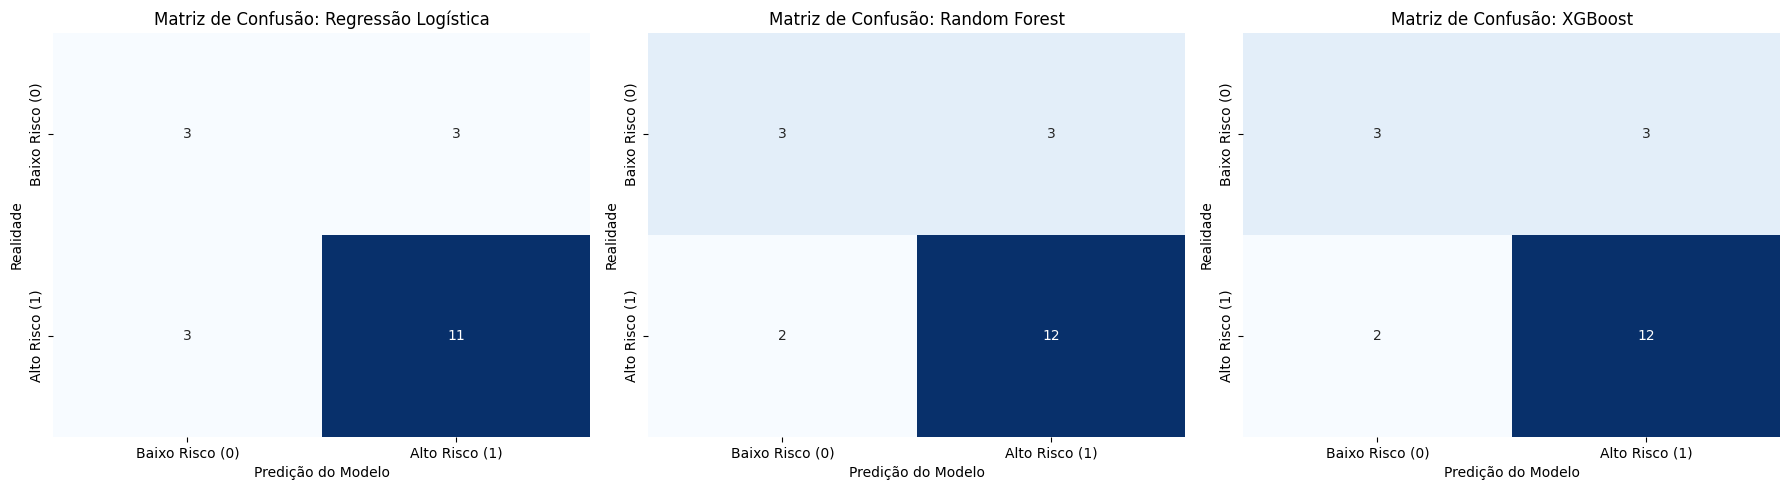


TABELA COMPARATIVA DE DESEMPENHO DOS MODELOS
             Modelo  Acurácia  Precisão  Recall (Sensibilidade)  F1-Score  ROC-AUC  Falsos Negativos (FN)  Falsos Positivos (FP)
Regressão Logística      0.70     0.786                   0.786     0.786    0.655                      3                      3
      Random Forest      0.75     0.800                   0.857     0.828    0.631                      2                      3
            XGBoost      0.75     0.800                   0.857     0.828    0.720                      2                      3


In [ ]:
# ============================================================
# ETAPA 5: AVALIAÇÃO DOS MODELOS E MATRIZ DE CONFUSÃO
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# 1. Dicionário com os modelos treinados e seus conjuntos de teste apropriados
modelos = {
    'Regressão Logística': (mdl_logreg, X_test_scaled),
    'Random Forest': (mdl_rf, X_test),
    'XGBoost': (mdl_xgb, X_test)
}

metricas_lista = []

# Configuração da figura para as Matrizes de Confusão
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (nome, (modelo, X_eval)) in enumerate(modelos.items()):
    # Predições de classe e probabilidades da classe positiva (RISK=1)
    y_pred = modelo.predict(X_eval)
    y_proba = modelo.predict_proba(X_eval)[:, 1]

    # Cálculo das métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)

    cm = confusion_matrix(y_test, y_pred)
    fn = cm[1, 0] # Falsos Negativos (Pet em risco classificado como normal)
    fp = cm[0, 1] # Falsos Positivos

    metricas_lista.append({
        'Modelo': nome,
        'Acurácia': round(acc, 3),
        'Precisão': round(prec, 3),
        'Recall (Sensibilidade)': round(rec, 3),
        'F1-Score': round(f1, 3),
        'ROC-AUC': round(auc, 3),
        'Falsos Negativos (FN)': fn,
        'Falsos Positivos (FP)': fp
    })

    # Plot da Matriz de Confusão
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['Baixo Risco (0)', 'Alto Risco (1)'],
                yticklabels=['Baixo Risco (0)', 'Alto Risco (1)'])
    axes[idx].set_title(f'Matriz de Confusão: {nome}')
    axes[idx].set_ylabel('Realidade')
    axes[idx].set_xlabel('Predição do Modelo')

plt.tight_layout()
plt.show()

# 2. Exibição da Tabela Comparativa de Desempenho
df_metricas = pd.DataFrame(metricas_lista)
print("\n" + "="*80)
print("TABELA COMPARATIVA DE DESEMPENHO DOS MODELOS")
print("="*80)
print(df_metricas.to_string(index=False))